<a href="https://colab.research.google.com/github/Suvanga/ML_DL/blob/main/Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pytorch Computer Vision
* `torch.vision` : https://www.learnpytorch.io/03_pytorch_computer_vision/
* `tourchvision.datasets` get datasets and data loading function  for computer from here
* `torchvision.models` - get oretrained computer vision models that you leverage for your own problems
* `tochvision.transforms` functions for manipulatinf the vision data to be suitable for use with ML model
* `torch.utils.data.Dataset` Base dataset class for Pytorch
* `torch.utils.data.DataLoader` - Creates a python iterable over a dataset

In [ ]:
import torch
from torch import nn

import pandas as pd
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor


import matplotlib.pyplot as plt


In [ ]:
##Training Data
train_data = datasets.FashionMNIST(
  root = "data", #Where to download the data to ?
  train = True, #get training data
  download = True, #download data if it doesn't exist
  transform=ToTensor(), #convert to tensor
  target_transform=None
)

In [ ]:
#Testing Data
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform=None
)


In [ ]:
len(train_data), len(test_data)

In [ ]:
##See the first training example
image , label = train_data[0]
image , label

In [ ]:
class_names = train_data.classes
class_names

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

In [ ]:
image.shape ,  label

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image Shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

In [ ]:
plt.imshow(image.squeeze(),cmap ="gray")
plt.title(class_names[label]);
plt.axis(False);

In [ ]:
# torch.manual_seed(42)
fig = plt.figure(figsize = (9,9))
rows, cols = 4,4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item() # Add parentheses here
  img , label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

In [ ]:
##Preparing Dara Loader
train_data, test_data

#Data Loader turns the dataset into a pythorn

#breaking them unto batches :

* It is more computationally efficient
* It may not be able to look stroe in memory

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)
test_dataloader = DataLoader(dataset = test_data,
                              batch_size = BATCH_SIZE,
                              shuffle = False)


In [ ]:
print(f"Data Loaders : {train_dataloader, test_dataloader} ")
print(f"Length of the dataloader : {len(train_dataloader)}batches of batch size {BATCH_SIZE}")
print(f"Length of the dataloader : {len(test_dataloader)}batches of batch size {BATCH_SIZE}")

In [ ]:
#show a sample
train_features_batch , train_labels_batch = next(iter(train_dataloader))

In [ ]:
train_features_batch.shape, train_labels_batch.shape

In [ ]:
random_idx = torch.randint(0, len(train_features_batch), size = [1]).item()
img ,label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap = "grey")
plt.title(class_names[label])
plt.axis(False)
print(f"Image size :{img.shape}")
print(f"Label : {label}, label size = {label.shape}")


##Building a baseline model for torch vision

* When starting t build ml model, it is best practice to start with baseline model
* A baseline model is a simple model we will tryn and improve upon with subsequent model/experiment


In [ ]:
flatten_model = nn.Flatten()

x = train_features_batch[0]

output = flatten_model(x) # perform forward pass

# printing out whatr happened

print(f"Shape before flattening {x.shape}")
print(f"Shape after flattening {output.shape}")


In [ ]:
# to reduce the dinmensionality of lots of features bsaically a flatten is used

class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape:int,hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape,
                  out_features = hidden_units),
        nn.Linear(in_features = hidden_units,
                  out_features = output_shape)
        )
  def forward(self, x)->torch.tensor:
          return self.layer_stack(x)

In [ ]:
#creating a n instance of the model
model_0 = FashionMNISTModelV0(
    input_shape = 784,
    hidden_units= 10,
    output_shape = len(class_names)
).to("cpu")

In [ ]:
model_0

In [ ]:
dummy_x = torch.rand([1,1,28,28])

In [ ]:
model_0(dummy_x)

In [ ]:
model_0.state_dict()


#what wil our loss Function be ?
* since we have used all the multi class data our loss function will be `nn.CrossEntropyLoss()`
* Optimizer we are ging to be using is torch.optim.sgd
* we can use a torchmetrics to ise the libbrary and we could copy the finction straight in to our notebook  and  Calculate accuracy


In [ ]:
##Iporting helperfuunctions.py

import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functoins already exist")
else:
  requests = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb")as f: ##this sets the permissipon of the file to write binary functions here in the file
    f.write(requests.content)  #now we write the contents inside the helper function.py file we just created





In [ ]:
from helper_functions import accuracy_fn





In [ ]:
#setting up loss function and optimizer
Loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)
#creating a function to time pour experiment


#creating a function to time our experiments

* Machine learning is very experimental, twi of the main thing you would want to track is the model performance etc and the second part is how fast it runs



In [ ]:
from timeit import default_timer as timer
def train_time(start:float,
               end:float,
               device: torch.device = None):
  total_time = end-start
  print(f"Total Time on {device} : {total_time:.3f} seconds")
  return total_time

In [ ]:
#sample on how to use the timeit funciton

start_time = timer()
"""
Some code
"""
end_time = timer()
print(f"total time : {train_time(start_time, end_time)}")

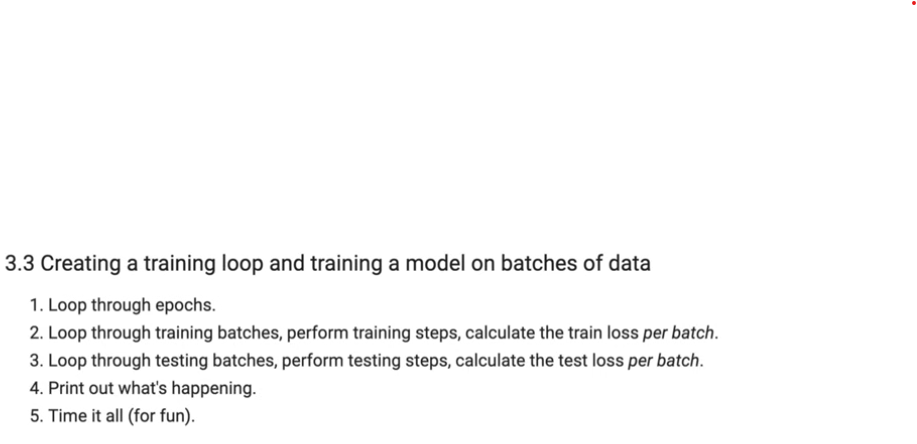

In [ ]:
len(train_dataloader)

In [ ]:
from tqdm.auto import tqdm

#Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

#set the number of epochs
epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n------")

    ##training
    train_loss = 0
    # add a loop to loop through training loop
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        #1 do the forward pass
        y_pred = model_0(X)
        #2 calculate the loss
        loss = Loss_fn(y_pred, y)
        train_loss += loss
        #Optimizer zero grad
        optimizer.zero_grad()
        #loss backward
        loss.backward()
        #optimizer step
        optimizer.step()
        if batch %400 == 0:
          print(f"Looked at : {batch*32}/ {len(train_dataloader.dataset)} samples ")
    train_loss/=len(train_dataloader)

    #Testing
    test_loss, test_acc = 0,0
    model_0.eval()
    with torch.inference_mode():
      for X_test, y_test in test_dataloader:
        #forward pass
        test_pred = model_0(X_test) # Corrected: Use X_test here
        #calculate the accuracy
        test_loss += Loss_fn(test_pred, y_test) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
        test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

        # valculate the abg per batch
      test_loss/=len(test_dataloader)
      test_acc/=len(test_dataloader)

      print(f"\n Train Loss:{train_loss:.4f} | Test Loss {test_loss:.4f},Test acc {test_acc}")

      train_time_end_on_cpu = timer()
      toral_train_time_model_0 = train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device = str(next(model_0.parameters()).device))
      print(f"Total training time : {toral_train_time_model_0}")

In [ ]:
##Make predictions and get model_ 0 results
#building multiple models
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device = device):
  loss, acc =0,0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device) # Corrected: Reassign X and y to their device-moved versions
      y_pred = model(X)

      #accumulate the loss and accuracy value per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

    return {"model_name" : model.__class__.__name__,
            "model_loss" : loss.item(),
            "model_acc" : acc}

In [ ]:
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=Loss_fn,
                             accuracy_fn=accuracy_fn)

In [ ]:
model_0_results.items()

In [ ]:
##setup some device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
device

In [ ]:
!nvidia-smi

In [ ]:
#Training the model 1 , and for future making a generic
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape :int, hidden_units :int, output_shape :int):
    super().__init__()
    self.non_LinearStack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )
  def forward(self, x: torch.Tensor):
    return self.non_LinearStack(x)

In [ ]:
#creating the instance of model 1
model_1 = FashionMNISTModelV1(input_shape = 784, hidden_units=10, output_shape=len(class_names)).to(device)

In [ ]:
loss_fn2 = torch.nn.CrossEntropyLoss()
optimizer2 = torch.optim.SGD(params=model_1.parameters(), lr=0.1)



In [ ]:
# #model that runs in the GPU and building the one that harnesses the power of non linearity

# torch.manual_seed(42)
# torch.cuda.manual_seed(42)

# Epochs = 3

# for epoch in tqdm(range(Epochs)):
#   print(f"Epoch {epoch}\n------")
#   train_loss, accuracy  = 0 , 0
#   model_1.train()

#   for batch, (X,y) in enumerate(train_dataloader):
#     X, y = X.to(device), y.to(device)
#     y_pred = model_1(X)

#     loss = loss_fn2(y_pred, y)
#     train_loss += loss
#     accuracy += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

#     optimizer2.zero_grad()
#     loss.backward()
#     optimizer2.step()


#   train_loss/=len(train_dataloader)
#   accuracy /= len(train_dataloader)
#   print(f"{epoch+1}: train loss is {train_loss} | accuracy is {accuracy}" )





#writing the code to make the train step
#functionizing training and testing loop

* Training Loop and testing loop

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               optimizer: torch.optim.Optimizer,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
  train_loss, train_acc = 0, 0
  model.train()
  # add a loop to loop through training loop
  for batch, (X, y) in enumerate(data_loader):
          X , y = X.to(device), y.to(device)

          #1 do the forward pass
          y_pred = model(X)

          #2 calculate the loss
          loss = Loss_fn(y_pred, y)
          train_loss += loss
          train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

          #Optimizer zero grad
          optimizer.zero_grad()

          #loss backward
          loss.backward()

          #optimizer step
          optimizer.step()

  train_loss/=len(data_loader)
  train_acc/=len(data_loader)
  print(f"\n Train Loss:{train_loss:.4f} average accuracy: {train_acc} ")



In [ ]:
def test_step(model:torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device : torch.device = device):
  model.eval()
  test_loss, test_acc = 0 , 0
  with torch.inference_mode():
    model.eval()
    for X_test, y_test in data_loader:
      #changing the data to device
      X_test, y_test = X_test.to(device), y_test.to(device)

      # Forward pass
      y_test_pred = model(X_test)

      #calculate the loss
      test_loss += loss_fn(y_test_pred, y_test)
      test_acc += accuracy_fn(y_true=y_test, y_pred=y_test_pred.argmax(dim =1))

    #adjust metrics and print out

    test_loss /= len(data_loader)
    test_acc  /= len(data_loader)
    print(f"Test Loss : {test_loss} | Test accuracy: {test_acc}")

In [ ]:
loss_fn2 = torch.nn.CrossEntropyLoss()
optimizer2 = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

from timeit import default_timer as timer
train_time_start_on_gpu = timer()

Epochs = 3

for epoch in tqdm(range(Epochs)):
  print(f"Epoch {epoch}\n------")
  train_step(model=model_1,
             data_loader = train_dataloader,
             optimizer=optimizer2,
             loss_fn=loss_fn2,
             accuracy_fn=accuracy_fn,
             device = device)
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn2,
            accuracy_fn=accuracy_fn,
            device=device)
train_time_end_on_gpu = timer()
Total_train_time = train_time(start = train_time_start_on_gpu, end = train_time_end_on_gpu, device = device)


In [ ]:
model_0_results

In [ ]:
toral_train_time_model_0

In [ ]:
!nvidia-smi

In [ ]:
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn2,
                             accuracy_fn=accuracy_fn,
                             device = device)